# A separate notebook for the boxplots of mean variables

In [1]:
from case_functions import *
from compositing_functions import *


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



In [2]:
# No 20220524, 20230611, 20230613 (all nontor) due to lack of FF obs, and 20240502
# dates = ['20220523', '20220611','20230524', '20230527', '20230601', '20230609',
#          '20230612', '20230615', '20240427', '20240501', '20240504', '20240506', '20240519'
#           '20240523', '20240528', '20240602']

# GETTING RID OF 20240504 AND 20240502 BECAUSE IT WAS TOO HIGH (TOO LOW), STRANGE OUTLIER AND 20240528
dates = ['20220523', '20220524','20220611','20230524', '20230527', '20230601', '20230609',
        '20230611', '20230612', '20230613','20230615', '20240427', '20240501', '20240506', '20240519'
          '20240523', '20240528', '20240602']
kas = ['ka1', 'ka2']
heights = np.arange(50, 2010, 10)

In [3]:
df_all_new = pd.DataFrame()
#for ka in kas:
for d in dates:
    for file in glob.glob(f'case_dfs/new/new_secondtrip/*/{d}_uv_*_all.csv'):
        try:
            not_comp_file_name_new = file
            print(not_comp_file_name_new)
            df_new = pd.read_csv(not_comp_file_name_new)
            df_new['Date'] = d
            print(np.shape(df_new))
            if df_new['Time From Tor (min)'].eq('nontor').any():
                df_new['Tor or Nontor'] = 'nontor'
            else:
                df_new['Tor or Nontor'] = 'tor'
                
            df_all_new = pd.concat([df_all_new, df_new], ignore_index=True)
        except FileNotFoundError:
            print(f"File not found: {not_comp_file_name_new}")
            continue

case_dfs/new/new_secondtrip/tornadic/20220523_uv_ka1_all.csv
(120, 202)
case_dfs/new/new_secondtrip/tornadic/20220523_uv_ka2_all.csv
(20, 202)
case_dfs/new/new_secondtrip/nontornadic/20220524_uv_ka1_all.csv
(100, 202)
case_dfs/new/new_secondtrip/tornadic/20230524_uv_ka2_all.csv
(284, 202)
case_dfs/new/new_secondtrip/tornadic/20230527_uv_ka1_all.csv
(506, 202)
case_dfs/new/new_secondtrip/nontornadic/20230611_uv_ka1_all.csv
(388, 202)
case_dfs/new/new_secondtrip/nontornadic/20230612_uv_ka2_all.csv
(198, 202)
case_dfs/new/new_secondtrip/nontornadic/20230613_uv_ka1_all.csv
(20, 202)
case_dfs/new/new_secondtrip/tornadic/20230615_uv_ka1_all.csv
(572, 202)
case_dfs/new/new_secondtrip/tornadic/20230615_uv_ka2_all.csv
(352, 202)
case_dfs/new/new_secondtrip/nontornadic/20240427_uv_ka1_all.csv
(314, 202)
case_dfs/new/new_secondtrip/nontornadic/20240501_uv_ka1_all.csv
(850, 202)
case_dfs/new/new_secondtrip/nontornadic/20240528_uv_ka1_all.csv
(1050, 202)
case_dfs/new/new_secondtrip/tornadic/2024060

In [4]:
df_all_new['NF or FF'] = np.where(df_all_new['Distance'] <= 30, 'nf', 'ff')

In [5]:
# Get the list of column names greater than 100
#cols_above_100 = [str(i) for i in range(101, 199)]  # up to 198

#cols_above_100 = [col for col in df_all_new.columns if col.isdigit() and 100 <= int(col) <= 198]
# Set those columns to NaN for the target date
#df_all_new.loc[df_all_new['Date'] == '20240501', cols_above_100] = np.nan

#df_all_new.loc[df_all_new['Date'] == '20240528', cols_above_100] = np.nan

In [6]:
vad_df = df_all_new[df_all_new['Date'] == '20220523']
morton = pd.read_csv('/Users/juliabman/Desktop/storm_events_data/storm_data_search_results_20220523.csv')
tor_df, tor_nontor = tor_id_new_time(vad_df, morton, str('Tornado'), ['MORTON', 'MORTON COCHRAN CO AR', 'ENOCHS', 'PETTIT', 'PEP', 'COBLE'], str('US/Central'), False)
times = time_from_tor(vad_df, morton, str('Tornado'), ['MORTON', 'MORTON COCHRAN CO AR', 'ENOCHS', 'PETTIT', 'PEP', 'COBLE'], str('US/Central'), False)
vad_df['Time From Tor (min)'] = times
df_all_new.loc[df_all_new['Date'] == '20220523', 'Time From Tor (min)'] = times

1750 MORTON
1803 MORTON
1812 ENOCHS
1813 MORTON COCHRAN CO AR
1817 ENOCHS
1840 MORTON COCHRAN CO AR
1906 PEP
1914 MORTON COCHRAN CO AR
1928 PETTIT
1937 PETTIT
1940 COBLE
2022-05-23 17:50:00
2022-05-23 18:03:00
2022-05-23 18:12:00
2022-05-23 18:13:00
2022-05-23 18:17:00
2022-05-23 18:40:00
2022-05-23 19:06:00
2022-05-23 19:14:00
2022-05-23 19:28:00
2022-05-23 19:37:00
2022-05-23 19:40:00
2022-05-23 23:50:00+00:00
1750 MORTON
1803 MORTON
1812 ENOCHS
1813 MORTON COCHRAN CO AR
1817 ENOCHS
1840 MORTON COCHRAN CO AR
1906 PEP
1914 MORTON COCHRAN CO AR
1928 PETTIT
1937 PETTIT
1940 COBLE
2022-05-23 17:50:00
2022-05-23 18:03:00
2022-05-23 18:12:00
2022-05-23 18:13:00
2022-05-23 18:17:00
2022-05-23 18:40:00
2022-05-23 19:06:00
2022-05-23 19:14:00
2022-05-23 19:28:00
2022-05-23 19:37:00
2022-05-23 19:40:00
start:2022-05-23 23:50:00+00:00
end:2022-05-24 01:58:00+00:00


In [7]:
d = '20230615'
vad_df = df_all_new[df_all_new['Date'] == d]
tor_data = pd.read_csv(f'/Users/juliabman/Desktop/storm_events_data/storm_data_search_results_{d}.csv')
tor_df, tor_nontor = tor_id_new_time(vad_df, tor_data, str('Tornado'), list(np.array(tor_data.BEGIN_LOCATION)), str('US/Central'), False)
times = time_from_tor(vad_df, tor_data, str('Tornado'), list(np.array(tor_data.BEGIN_LOCATION)), str('US/Central'), False)
#vad_df['Tor Times'] = tor_df
#vad_df['Tor or Nontor'] = tor_nontor
vad_df['Time From Tor (min)'] = times

df_all_new.loc[df_all_new['Date'] == d, 'Time From Tor (min)'] = times

1558 FAXON
1610 WALTERS ARPT
1611 EMPIRE CITY
1634 SUNRAY
1637 COMANCHE
1658 SUGDEN
1703 LOCO
1716 LOCO
1721 RINGLING
1731 ARNETT
1747 DURHAM
1826 MARIETTA
2023-06-15 15:58:00
2023-06-15 16:10:00
2023-06-15 16:11:00
2023-06-15 16:34:00
2023-06-15 16:37:00
2023-06-15 16:58:00
2023-06-15 17:03:00
2023-06-15 17:16:00
2023-06-15 17:21:00
2023-06-15 17:31:00
2023-06-15 17:47:00
2023-06-15 18:26:00
2023-06-15 21:58:00+00:00
1558 FAXON
1610 WALTERS ARPT
1611 EMPIRE CITY
1634 SUNRAY
1637 COMANCHE
1658 SUGDEN
1703 LOCO
1716 LOCO
1721 RINGLING
1731 ARNETT
1747 DURHAM
1826 MARIETTA
2023-06-15 15:58:00
2023-06-15 16:10:00
2023-06-15 16:11:00
2023-06-15 16:34:00
2023-06-15 16:37:00
2023-06-15 16:58:00
2023-06-15 17:03:00
2023-06-15 17:16:00
2023-06-15 17:21:00
2023-06-15 17:31:00
2023-06-15 17:47:00
2023-06-15 18:26:00
start:2023-06-15 21:58:00+00:00
end:2023-06-16 00:27:00+00:00


In [8]:
srw_all = []
srw_sfc = []

for d in set(df_all_new['Date']):

    
    df_u = df_all_new[(df_all_new['Date'] == d) & (df_all_new['u or v'] == 'u')]
    df_v = df_all_new[(df_all_new['Date'] == d) & (df_all_new['u or v'] == 'v')]

    bulkshear0100 = bulk_shear(df_u.iloc[:,0], df_v.iloc[:,0], df_u.iloc[:,10], df_v.iloc[:,10])
    bulkshear0250 = bulk_shear(df_u.iloc[:,0], df_v.iloc[:,0], df_u.iloc[:,25], df_v.iloc[:,25])
    bulkshear0500 = bulk_shear(df_u.iloc[:,0], df_v.iloc[:,0], df_u.iloc[:,50], df_v.iloc[:,50])
    bulkshear01 = bulk_shear(df_u.iloc[:,0], df_v.iloc[:,0], df_u.iloc[:,100], df_v.iloc[:,100])
    bulkshear02 = bulk_shear(df_u.iloc[:,0], df_v.iloc[:,0], df_u.iloc[:,195], df_v.iloc[:,195])

    df_all_new.loc[df_u.index, '0-100m Bulk Shear Mag'] = bulkshear0100
    df_all_new.loc[df_u.index, '0-250m Bulk Shear Mag'] = bulkshear0250
    df_all_new.loc[df_u.index, '0-500m Bulk Shear Mag'] = bulkshear0500
    df_all_new.loc[df_u.index, '0-1km Bulk Shear Mag'] = bulkshear01
    df_all_new.loc[df_u.index, '0-2km Bulk Shear Mag'] = bulkshear02

    df_all_new.loc[df_v.index, '0-100m Bulk Shear Mag'] = bulkshear0100
    df_all_new.loc[df_v.index, '0-250m Bulk Shear Mag'] = bulkshear0250
    df_all_new.loc[df_v.index, '0-500m Bulk Shear Mag'] = bulkshear0500
    df_all_new.loc[df_v.index, '0-1km Bulk Shear Mag'] = bulkshear01
    df_all_new.loc[df_v.index, '0-2km Bulk Shear Mag'] = bulkshear02
    
    srw_values_sfc = comp_srw(df_u, df_v, 0)
    
    df_all_new.loc[df_u.index, 'SFC SRW Mag'] = srw_values_sfc  # Assign to correct indices
    df_all_new.loc[df_v.index, 'SFC SRW Mag'] = srw_values_sfc

    srw_values_100 = comp_srw(df_u, df_v, 10)
    
    df_all_new.loc[df_u.index, '0-100m SRW Mag'] = srw_values_100  # Assign to correct indices
    df_all_new.loc[df_v.index, '0-100m SRW Mag'] = srw_values_100

    srw_values_250 = comp_srw(df_u, df_v, 25)
    
    df_all_new.loc[df_u.index, '0-250m SRW Mag'] = srw_values_250  # Assign to correct indices
    df_all_new.loc[df_v.index, '0-250m SRW Mag'] = srw_values_250

    srw_values_500 = comp_srw(df_u, df_v, 50)
    
    df_all_new.loc[df_u.index, '0-500m SRW Mag'] = srw_values_500  # Assign to correct indices
    df_all_new.loc[df_v.index, '0-500m SRW Mag'] = srw_values_500

    srw_values_1km = comp_srw(df_u, df_v, 100)
    
    df_all_new.loc[df_u.index, '0-1km SRW Mag'] = srw_values_1km  # Assign to correct indices
    df_all_new.loc[df_v.index, '0-1km SRW Mag'] = srw_values_1km

    srw_values_2km = comp_srw(df_u, df_v, 194)
    df_all_new.loc[df_u.index, '0-2km SRW Mag'] = srw_values_2km  # Assign to correct indices
    df_all_new.loc[df_v.index, '0-2km SRW Mag'] = srw_values_2km

In [9]:
srh_all = []
srh_0to2km = []

for d in set(df_all_new['Date']):

    
    df_u = df_all_new[(df_all_new['Date'] == d) & (df_all_new['u or v'] == 'u')]
    df_v = df_all_new[(df_all_new['Date'] == d) & (df_all_new['u or v'] == 'v')]

    #print(range(len(df_u)))
    
    srh_values02 = [
        composite_srh_nan(df_u.iloc[i, :196], df_v.iloc[i, :196]) 
        for i in range(len(df_u))
    ]

    srh_values01 = [
        composite_srh_nan(df_u.iloc[i, :96], df_v.iloc[i, :96]) 
        for i in range(len(df_u))
    ]

    srh_values05 = [
        composite_srh_nan(df_u.iloc[i, :50], df_v.iloc[i, :50]) 
        for i in range(len(df_u))
    ]

    srh_values025 = [
        composite_srh_nan(df_u.iloc[i, :25], df_v.iloc[i, :25]) 
        for i in range(len(df_u))
    ]

    srh_values10 = [
        composite_srh_nan(df_u.iloc[i, :10], df_v.iloc[i, :10]) 
        for i in range(len(df_u))
    ]

    df_all_new.loc[df_u.index, '0-100m SRH'] = srh_values10  # Assign to correct indices
    df_all_new.loc[df_v.index, '0-100m SRH'] = srh_values10
    
    df_all_new.loc[df_u.index, '0-250m SRH'] = srh_values025  # Assign to correct indices
    df_all_new.loc[df_v.index, '0-250m SRH'] = srh_values025
    
    df_all_new.loc[df_u.index, '0-500m SRH'] = srh_values05  # Assign to correct indices
    df_all_new.loc[df_v.index, '0-500m SRH'] = srh_values05
    
    df_all_new.loc[df_u.index, '0-1km SRH'] = srh_values01  # Assign to correct indices
    df_all_new.loc[df_v.index, '0-1km SRH'] = srh_values01
    
    df_all_new.loc[df_u.index, '0-2km SRH'] = srh_values02  # Assign to correct indices
    df_all_new.loc[df_v.index, '0-2km SRH'] = srh_values02


In [10]:
us = df_all_new[df_all_new['u or v'] == 'u']
vs = df_all_new[df_all_new['u or v'] == 'v']

u0 = np.array(us.iloc[:, 0])
v0 = np.array(vs.iloc[:, 0])

u100 = np.array(us.iloc[:, 10])
v100 = np.array(vs.iloc[:, 10])

u250 = np.array(us.iloc[:, 25])
v250 = np.array(vs.iloc[:, 25])

u500 = np.array(us.iloc[:, 50])
v500 = np.array(vs.iloc[:, 50])

critical_angle_degu10 = compute_critical_angle(u0, v0, u100, v100, u0, v0)
critical_angle_degv10 = compute_critical_angle(u0, v0, u100, v100, u0, v0)

critical_angle_degu25 = compute_critical_angle(u0, v0, u250, v250, u0, v0)
critical_angle_degv25 = compute_critical_angle(u0, v0, u250, v250, u0, v0)

critical_angle_degu = compute_critical_angle(u0, v0, u500, v500, u0, v0)
critical_angle_degv = compute_critical_angle(u0, v0, u500, v500, u0, v0)

df_all_new.loc[df_all_new['u or v'] == 'u', '0-100m Critical_Angle'] = critical_angle_degu10
df_all_new.loc[df_all_new['u or v'] == 'v', '0-100m Critical_Angle'] = critical_angle_degv10

df_all_new.loc[df_all_new['u or v'] == 'u', '0-250m Critical_Angle'] = critical_angle_degu25
df_all_new.loc[df_all_new['u or v'] == 'v', '0-250m Critical_Angle'] = critical_angle_degv25

df_all_new.loc[df_all_new['u or v'] == 'u', '0-500m Critical_Angle'] = critical_angle_degu
df_all_new.loc[df_all_new['u or v'] == 'v', '0-500m Critical_Angle'] = critical_angle_degv

In [11]:
nf_dist = 30
ff_dist = 50
minangle = 0
midangle = 45
maxangle = 90

In [12]:
avg_comp = pd.DataFrame()

for d in sorted(set(df_all_new['Date'])):
    tor_df = pd.DataFrame()
    nontor_df = pd.DataFrame()
    df = df_all_new[(df_all_new['u or v'] == 'u') & (df_all_new['Date'] == d) & (df_all_new['Angle'] >= minangle) & (df_all_new['Angle'] <= maxangle) & (df_all_new['Distance'] < 50)]
    #df = dd
    
    if df['Tor or Nontor'].eq('tor').any():
        pretor = df[df['Time From Tor (min)'] < 0]
        dtor = df[df['Time From Tor (min)'] == 0]
        posttor = df[df['Time From Tor (min)'] > 0]
        pretor_df = comp_per_condition_new(pretor, nf_dist, ff_dist, minangle, midangle, maxangle)
        dtor_df = comp_per_condition_new(dtor, nf_dist, ff_dist, minangle, midangle, maxangle)
        posttor_df = comp_per_condition_new(posttor, nf_dist, ff_dist, minangle, midangle, maxangle)

        pretor_df['Tor Time'] = 'pretor'
        dtor_df['Tor Time'] = 'dtor'
        posttor_df['Tor Time'] = 'posttor'

        tor_df = pd.concat([pretor_df, dtor_df, posttor_df])
        tor_df['Tor or Nontor'] = 'tor'
        tor_df['Date'] = d

    elif df['Tor or Nontor'].eq('nontor').any():
        nontor = comp_per_condition_new(df, nf_dist, 40, minangle, midangle, maxangle)
        nontor['Tor or Nontor'] = 'nontor'
        nontor['Date'] = d
        nontor['Tor Time'] = 'nontor'

        nontor_df = pd.concat([nontor_df, nontor])
 
    avg_comp = pd.concat([avg_comp, tor_df, nontor_df], ignore_index=True)

In [13]:
avg_comp_nfff = pd.DataFrame()

for d in sorted(set(df_all_new['Date'])):
    tor_df = pd.DataFrame()
    nontor_df = pd.DataFrame()
    df = df_all_new[df_all_new['u or v'] == 'u']
    df = df[df['Date'] == d]

    
    if df['Tor or Nontor'].eq('tor').any():
        has_nf = (df['Distance'] < nf_dist).any() # nf_dist used to be 21
        has_ff = ((df['Distance'] < 50) & (df['Distance'] > nf_dist)).any()
        
        if has_nf and has_ff:
            pretor = df[df['Time From Tor (min)'] < 0]
            dtor = df[df['Time From Tor (min)'] == 0]
            posttor = df[df['Time From Tor (min)'] > 0]
            pretor_df = comp_per_condition_new(pretor, nf_dist, ff_dist, minangle, midangle, maxangle)
            dtor_df = comp_per_condition_new(dtor, nf_dist, ff_dist, minangle, midangle, maxangle)
            posttor_df = comp_per_condition_new(posttor, nf_dist, ff_dist, minangle, midangle, maxangle)
    
            pretor_df['Tor Time'] = 'pretor'
            dtor_df['Tor Time'] = 'dtor'
            posttor_df['Tor Time'] = 'posttor'
    
            tor_df = pd.concat([pretor_df, dtor_df, posttor_df])
            tor_df['Tor or Nontor'] = 'tor'
            tor_df['Date'] = d

    elif df['Tor or Nontor'].eq('nontor').any():
        has_nf = (df['Distance'] < nf_dist).any()
        has_ff = ((df['Distance'] < 50) & (df['Distance'] > nf_dist)).any()
        if has_nf and has_ff:
            nontor = comp_per_condition_new(df, nf_dist, 40, minangle, midangle, maxangle)
            nontor['Tor or Nontor'] = 'nontor'
            nontor['Date'] = d
            nontor['Tor Time'] = 'nontor'
    
            nontor_df = pd.concat([nontor_df, nontor])

    else:
        continue
    
 
    avg_comp_nfff = pd.concat([avg_comp_nfff, tor_df, nontor_df], ignore_index=True)

In [14]:
avg_comp_pred = pd.DataFrame()

for d in sorted(set(df_all_new['Date'])):
    tor_df = pd.DataFrame()
    nontor_df = pd.DataFrame()
    df = df_all_new[(df_all_new['u or v'] == 'u') & (df_all_new['Date'] == d)]
    
    if df['Tor or Nontor'].eq('tor').any():
        # Check that both pretor and dtor times exist
        has_pretor = (df['Time From Tor (min)'] < 0).any()
        has_dtor = (df['Time From Tor (min)'] == 0).any()
        has_posttor = (df['Time From Tor (min)'] > 0).any()

        if has_pretor and has_dtor and has_posttor:
            pretor = df[df['Time From Tor (min)'] < 0]
            dtor = df[df['Time From Tor (min)'] == 0]
            posttor = df[df['Time From Tor (min)'] > 0]

            pretor_df = comp_per_condition_new(pretor, nf_dist, ff_dist, minangle, midangle, maxangle)
            dtor_df = comp_per_condition_new(dtor, nf_dist, ff_dist, minangle, midangle, maxangle)
            posttor_df = comp_per_condition_new(posttor, nf_dist, ff_dist, minangle, midangle, maxangle)

            pretor_df['Tor Time'] = 'pretor'
            dtor_df['Tor Time'] = 'dtor'
            posttor_df['Tor Time'] = 'posttor'

            tor_df = pd.concat([pretor_df, dtor_df, posttor_df])
            tor_df['Tor or Nontor'] = 'tor'
            tor_df['Date'] = d

    elif df['Tor or Nontor'].eq('nontor').any():
        nontor = comp_per_condition_new(df, nf_dist, 40, minangle, midangle, maxangle)
        nontor['Tor or Nontor'] = 'nontor'
        nontor['Date'] = d
        nontor['Tor Time'] = 'nontor'

        nontor_df = pd.concat([nontor_df, nontor])
 
    avg_comp_pred = pd.concat([avg_comp_pred, tor_df, nontor_df], ignore_index=True)


In [15]:
pred_dist = avg_comp_pred.groupby(['Date', 'Tor Time', 'Height', 'SRW or SRH', 'Tor or Nontor', 'NF or FF'])[['Dist avg']].mean().reset_index()
pred_az = avg_comp_pred.groupby(['Date', 'Tor Time', 'Height', 'SRW or SRH', 'Tor or Nontor', 'Azimuth'])[['Angle avg']].mean().reset_index()

In [16]:
ttdist = pred_dist.groupby(['Date', 'Height', 'SRW or SRH', 'Tor or Nontor', 'Tor Time'])['Dist avg'].mean().reset_index()
ttaz = pred_az.groupby(['Date', 'Height', 'SRW or SRH', 'Tor or Nontor', 'Tor Time'])['Angle avg'].mean().reset_index()

In [17]:
ttdist = ttdist.dropna()
ttaz = ttaz.dropna()

In [18]:
tt = pd.concat([ttdist, ttaz], ignore_index=True)

In [19]:
comp_to_find_dist = avg_comp[(avg_comp['SRW or SRH'] == 'SRH') & (avg_comp['Height'] == '0-1km')]
avg_comp_dist = comp_to_find_dist.groupby(['Date', 'Tor or Nontor', 'NF or FF'])['Mean Distance'].mean().reset_index()
avg_comp_az = comp_to_find_dist.groupby(['Date', 'Tor or Nontor', 'Azimuth'])['Mean Angle'].mean().reset_index()
avg_comp_tor_nontor_dist = comp_to_find_dist.groupby(['Date', 'Tor or Nontor'])['Mean Distance'].mean().reset_index()

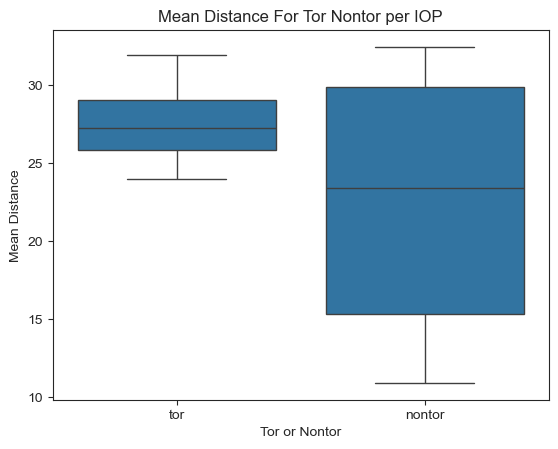

In [20]:
sns.boxplot(avg_comp_tor_nontor_dist, x='Tor or Nontor', y='Mean Distance')
plt.title('Mean Distance For Tor Nontor per IOP')
plt.show()

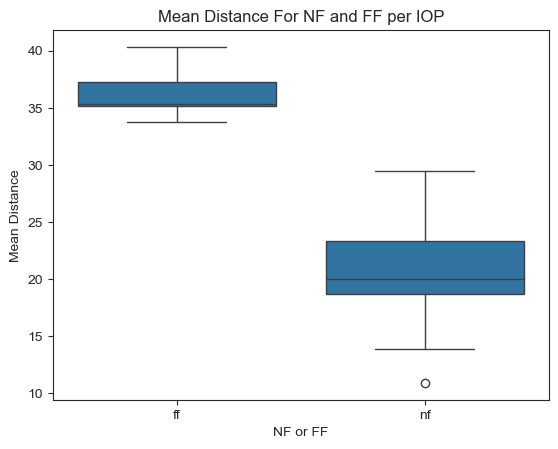

In [21]:
sns.boxplot(avg_comp_dist, x='NF or FF', y='Mean Distance')
plt.title('Mean Distance For NF and FF per IOP')
plt.show()

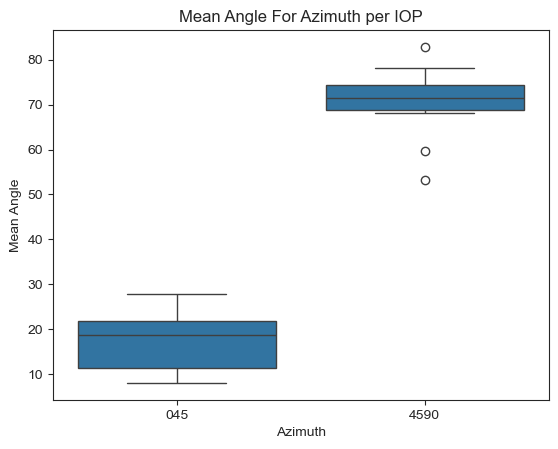

In [22]:
sns.boxplot(avg_comp_az, x='Azimuth', y='Mean Angle')
plt.title('Mean Angle For Azimuth per IOP')
plt.show()

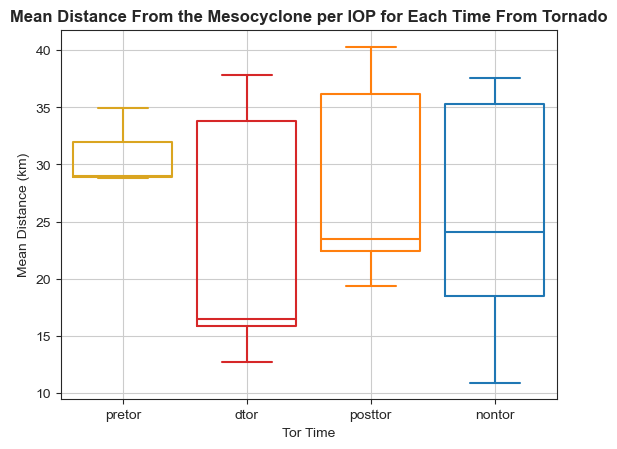

In [23]:
hue_order= ['nontor', 'pretor', 'dtor', 'posttor']

plot_data = avg_comp[(avg_comp['SRW or SRH'] == 'SRH') & (avg_comp['Height'] == '0-1km')]
sns.boxplot(plot_data, x='Tor Time', y='Mean Distance', hue='Tor Time', fill=False, palette =['tab:blue', 'goldenrod', 'tab:red', 'tab:orange', ], hue_order= ['nontor', 'pretor', 'dtor', 'posttor'])

# grouped = plot_data.groupby(['Tor Time'])['Mean Distance']

#     #dfa = pd.DataFrame()
    
# for i, ((x_val, hue_val), values) in enumerate(grouped):
#     median = np.median(values.dropna())
#     # Get the position on the x-axis using orderings
#     #x_index = height_order.index(x_val)
#     hue_index = hue_order.index(hue_val)
#     num_hues = len(hue_order)
    
#     # Calculate box position (adjust for hue spread)
#     xpos = x_index - 0.4 + (hue_index + 0.5) * (0.8 / num_hues)

#     ax.text(xpos, median, f'{median:.1f}', ha='center', va='bottom', fontsize=10, color='black')
    
plt.title('Mean Distance From the Mesocyclone per IOP for Each Time From Tornado', fontweight='bold', wrap=True)
plt.grid()
plt.ylabel('Mean Distance (km)')
#plt.xticks(ticks=[0, 1], labels=['0-45 degrees', '45-90 degrees'])
plt.show()

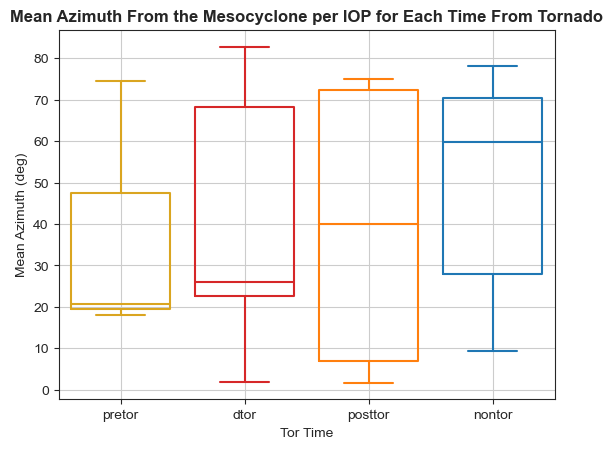

In [24]:
sns.boxplot(avg_comp[(avg_comp['SRW or SRH'] == 'SRH') & (avg_comp['Height'] == '0-1km')],x='Tor Time', y='Mean Angle', hue='Tor Time', fill=False, palette =['tab:blue', 'goldenrod', 'tab:red', 'tab:orange'], hue_order= ['nontor', 'pretor', 'dtor', 'posttor'])
plt.title('Mean Azimuth From the Mesocyclone per IOP for Each Time From Tornado', fontweight='bold', wrap=True)
plt.grid()
plt.ylabel('Mean Azimuth (deg)')
#plt.xticks(ticks=[0, 1], labels=['0-45 degrees', '45-90 degrees'])
plt.show()

In [25]:
dist_both = avg_comp_nfff.groupby(['Date', 'Tor or Nontor', 'Height', 'SRW or SRH', 'NF or FF'])[['Dist avg']].mean().reset_index()

In [26]:
summary = avg_comp.dropna().groupby(['Date', 'Tor Time', 'Height', 'SRW or SRH'])[['Dist avg']].mean().reset_index()

In [27]:
summarynotor = summary[(summary['Tor Time'] != 'nontor')]
toravg_all = summarynotor.groupby(['Date', 'Height', 'SRW or SRH'])[['Dist avg']].mean().reset_index()
#distnotor = avg_comp_dist[avg_comp_dist['Tor Time'] != 'nontor']
avg_comp_notor = avg_comp[(avg_comp['Tor Time'] != 'nontor')]
dist_tor_avg_all = avg_comp_notor.groupby(['Date', 'Height', 'SRW or SRH', 'NF or FF'])[['Dist avg']].mean().reset_index()
dist_tor_avg_nodate = avg_comp_notor.groupby(['Height', 'SRW or SRH', 'NF or FF'])[['Dist avg']].mean().reset_index()

#anglenotor = avg_comp_angle[avg_comp_angle['Tor Time'] != 'nontor']
angle_tor_avg_all = avg_comp_notor.groupby(['Date', 'Height', 'SRW or SRH', 'Azimuth'])[['Angle avg']].mean().reset_index()
angle_tor_avg_nodate = avg_comp_notor.groupby(['Height', 'SRW or SRH', 'Azimuth'])[['Angle avg']].mean().reset_index()

In [28]:
dist_tor_avg_all['Tor or Nontor'] = 'tor'
angle_tor_avg_all['Tor or Nontor'] = 'tor'

dist_tor_avg_nodate['Tor or Nontor'] = 'tor'
angle_tor_avg_nodate['Tor or Nontor'] = 'tor'

In [29]:
toravg_all['Tor Time'] = 'tor'

In [30]:
avg_tor_comp = toravg_all.groupby(['Height', 'SRW or SRH'])[['Dist avg']].mean().reset_index()

In [31]:
avg_tor_comp['Tor Time'] = 'tor'

In [32]:
summarynontor = summary[summary['Tor Time'] == 'nontor']
nontoravg_all = summarynontor.groupby(['Date', 'Height', 'SRW or SRH'])[['Dist avg']].mean().reset_index()
avg_nontor_comp = nontoravg_all.groupby(['Height', 'SRW or SRH'])[['Dist avg']].mean().reset_index()

avg_comp_nontor = avg_comp[avg_comp['Tor Time'] == 'nontor']
#distnontor = avg_comp_dist[avg_comp_dist['Tor Time'] == 'nontor']
dist_nontor_avg_all = avg_comp_nontor.groupby(['Date', 'Height', 'SRW or SRH', 'NF or FF'])[['Dist avg']].mean().reset_index()
dist_nontor_avg_nodate = avg_comp_nontor.groupby(['Height', 'SRW or SRH', 'NF or FF'])[['Dist avg']].mean().reset_index()

anglenontor = avg_comp_nontor[avg_comp_nontor['Tor Time'] == 'nontor']
angle_nontor_avg_all = avg_comp_nontor.groupby(['Date', 'Height', 'SRW or SRH', 'Azimuth'])[['Angle avg']].mean().reset_index()
angle_nontor_avg_nodate = avg_comp_nontor.groupby(['Height', 'SRW or SRH', 'Azimuth'])[['Angle avg']].mean().reset_index()

In [33]:
dist_nontor_avg_all['Tor or Nontor'] = 'nontor'
angle_nontor_avg_all['Tor or Nontor'] = 'nontor'

dist_nontor_avg_nodate['Tor or Nontor'] = 'nontor'
angle_nontor_avg_nodate['Tor or Nontor'] = 'nontor'

In [34]:
nontoravg_all['Tor Time'] = 'nontor'

In [35]:
avg_nontor_comp['Tor Time'] = 'nontor'

In [36]:
dist_angle = nontoravg_all[
        (nontoravg_all['Height'] == '0-100m') &
        (nontoravg_all['SRW or SRH'] == 'SRW') &
        (nontoravg_all['Tor Time'] == 'nontor')
    ]
dist_angle

,Date,Height,SRW or SRH,Dist avg,Tor Time
3,20230611,0-100m,SRW,18.519493,nontor
22,20240427,0-100m,SRW,26.958320,nontor
41,20240501,0-100m,SRW,23.449683,nontor
60,20240528,0-100m,SRW,12.714659,nontor


In [37]:
dist_angle_avg_date = pd.concat([dist_tor_avg_all, angle_tor_avg_all, dist_nontor_avg_all, angle_nontor_avg_all], ignore_index=True)

In [38]:
dist_angle_avg_nodate = pd.concat([dist_tor_avg_nodate, angle_tor_avg_nodate, dist_nontor_avg_nodate, angle_nontor_avg_nodate], ignore_index=True)

In [39]:
avg_all_comp_per_date = pd.concat([nontoravg_all, toravg_all], ignore_index=True)

In [40]:
avg_all_comp = pd.concat([avg_nontor_comp, avg_tor_comp], ignore_index=True)

In [41]:
avg_total_comp = summary.groupby(['Tor Time', 'Height', 'SRW or SRH'])[['Dist avg']].mean().reset_index()

# Boxplots

In [43]:
avg_all_comp_per_date['Variable'] = avg_all_comp_per_date['Height'] + ' ' + avg_all_comp_per_date['SRW or SRH']

In [44]:
sig_list = ['SFC SRW', '0-100m SRW', '0-500m SRH', '0-1km SRH', '0-2km SRH']

avg_all_comp_per_date['Sig'] = np.where(
    avg_all_comp_per_date['Variable'].isin(sig_list),
    'sig',
    'nonsig'
)

In [45]:
avg_all_comp_per_date

,Date,Height,SRW or SRH,Dist avg,Tor Time,Variable,Sig
0,20230611,0-100m,Bulk Shear,3.820704,nontor,0-100m Bulk Shear,nonsig
1,20230611,0-100m,Critical Angle,56.445993,nontor,0-100m Critical Angle,nonsig
2,20230611,0-100m,SRH,-2.780820,nontor,0-100m SRH,nonsig
3,20230611,0-100m,SRW,18.519493,nontor,0-100m SRW,sig
4,20230611,0-1km,Bulk Shear,11.561120,nontor,0-1km Bulk Shear,nonsig
...,...,...,...,...,...,...,...
147,20230615,0-500m,Bulk Shear,8.067879,tor,0-500m Bulk Shear,nonsig
148,20230615,0-500m,Critical Angle,80.655196,tor,0-500m Critical Angle,nonsig
149,20230615,0-500m,SRH,191.272838,tor,0-500m SRH,sig
150,20230615,0-500m,SRW,30.012551,tor,0-500m SRW,nonsig


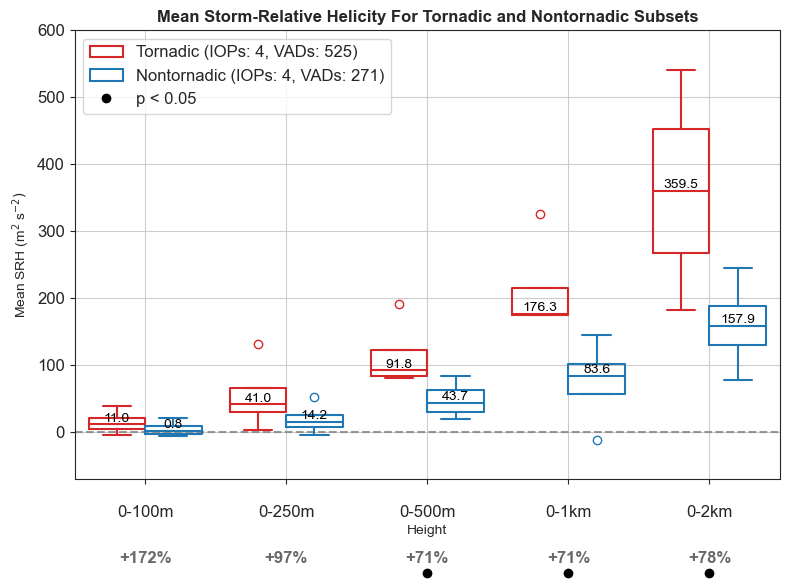

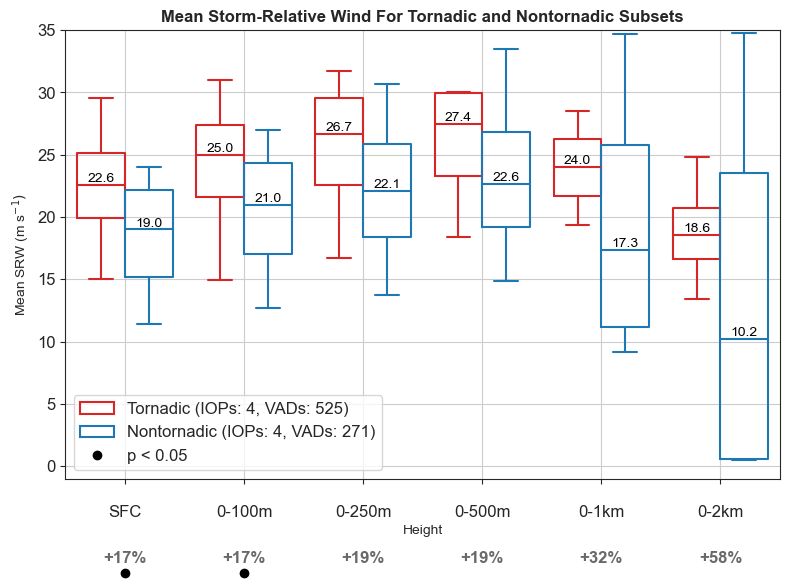

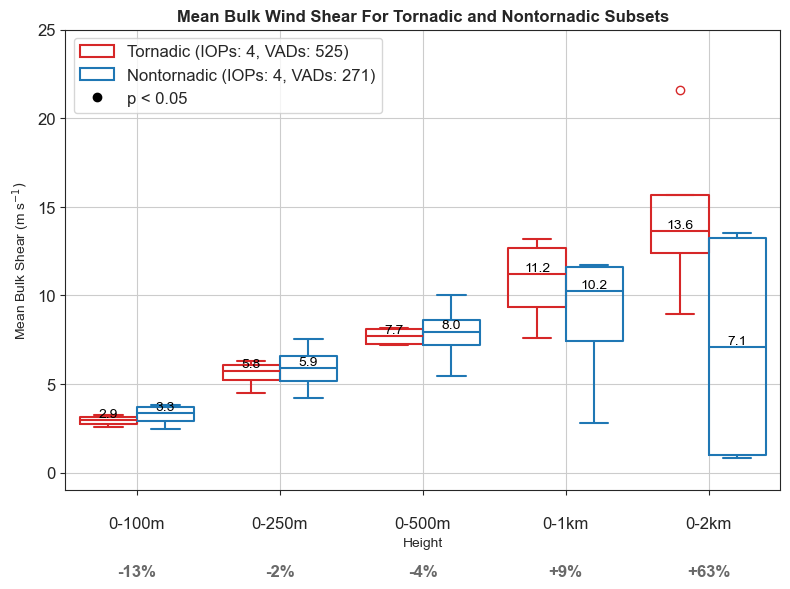

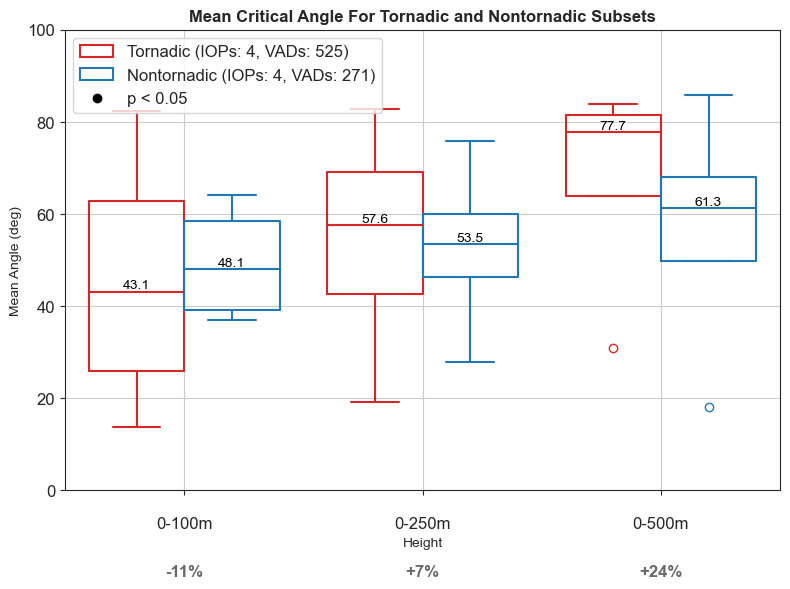

In [46]:
height_order = ['0-100m', '0-250m', '0-500m', '0-1km', '0-2km']
sfc_order = ['SFC', '0-100m', '0-250m', '0-500m', '0-1km', '0-2km']
ca_order = ['0-100m', '0-250m', '0-500m']

cmap = ['tab:red', 'tab:blue']
hue_order = ['tor', 'nontor']
legend_labels = ['Tornadic', 'Nontornadic']

plot_info = [
    ('SRH', 'Mean SRH (m$^{2}$ s$^{-2})$', 'Mean Storm-Relative Helicity For Tornadic and Nontornadic Subsets',
     height_order, (-70, 600)),

    ('SRW', 'Mean SRW (m s$^{-1})$', 'Mean Storm-Relative Wind For Tornadic and Nontornadic Subsets',
     sfc_order, (-1, 35)),

    ('Bulk Shear', 'Mean Bulk Shear (m s$^{-1})$', 'Mean Bulk Wind Shear For Tornadic and Nontornadic Subsets',
     height_order, (-1, 25)),

    ('Critical Angle', 'Mean Angle (deg)', 'Mean Critical Angle For Tornadic and Nontornadic Subsets',
     ca_order, (0, 100))
]

dfs = []

for variable, ylabel, title, order, ylim in plot_info:

    fig, ax = plt.subplots(figsize=(8, 6))

    if variable == 'SRH':
        plt.axhline(0, linestyle='--', color='gray', alpha=0.8)

    test = tor_nontor_boxplot(
        avg_all_comp_per_date,
        variable,
        'Height',
        'Dist avg',
        'tor',
        'nontor',
        False,
        _,
        'Tor Time',
        False,
        ylabel,
        title,
        ax,
        cmap,
        order,
        hue_order,
        legend_labels
    )
    dfs.append(test)

    ax.set_ylim(*ylim)

    # Build legend
    legend_patches = []

    for tnt in ['tor', 'nontor']:

        df = df_all_new[
            (df_all_new['u or v'] == 'v') &
            (df_all_new['Angle'] <= 90) &
            (df_all_new['Distance'] <= 50) &
            (df_all_new['Tor or Nontor'] == tnt)
        ]
        a = df['Tor or Nontor'].value_counts()

        dist_angle = avg_all_comp_per_date[
            (avg_all_comp_per_date['Height'] == '0-1km') &
            (avg_all_comp_per_date['SRW or SRH'] == 'SRH') &
            (avg_all_comp_per_date['Tor Time'] == tnt)
        ]

        tor_counts = dist_angle.groupby('Tor Time').size()

        colors = {'tor': 'tab:red', 'nontor': 'tab:blue'}
        dist_label_map = {'tor': 'Tornadic', 'nontor': 'Nontornadic'}

        if tnt in tor_counts:
            legend_patches.append(
                Patch(
                    facecolor='none',
                    edgecolor=colors[tnt],
                    linewidth=1.5,
                    label=f"{dist_label_map[tnt]} "
                          f"(IOPs: {tor_counts.get(tnt,0)}, "
                          f"VADs: {a.get(tnt,0)})"
                )
            )
    
    # Add significance marker
    legend_patches.append(
        Line2D(
            [0], [0],
            marker='o',
            color='black',
            linestyle='None',
            markersize=6,
            label='p < 0.05'
        )
    )
    
    labels = legend_labels + ['p < 0.05']

    ax.legend(handles=legend_patches, loc='upper left', fontsize=12)
    ax.set_title(title, fontweight='bold')
    
    if variable == 'SRW':
        ax.legend(handles=legend_patches, loc='lower left', fontsize=12)

    plt.tight_layout()
    plt.show()
pct_diff_df = pd.concat(dfs, ignore_index=True)

In [47]:
dist_angle_avg_date['NF or FF']

0       ff
1       nf
2       ff
3       nf
4       ff
      ... 
755    NaN
756    NaN
757    NaN
758    NaN
759    NaN
Name: NF or FF, Length: 760, dtype: object

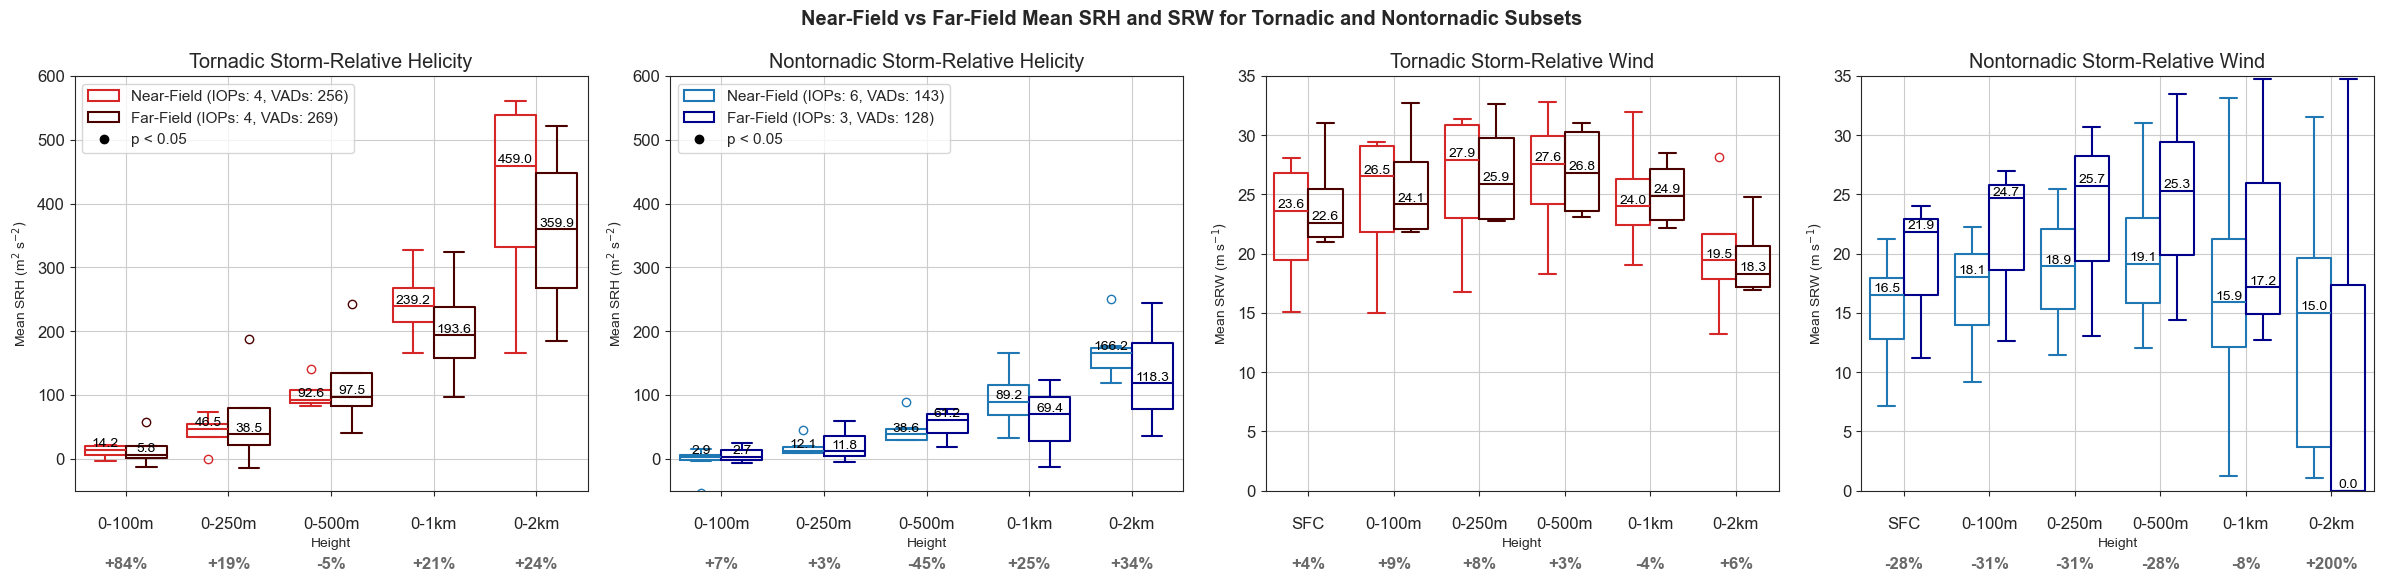

In [48]:
#df_all_new['NF or FF'] = np.where(df_all_new['Distance'] <= 30, 'nf', 'ff')
height_order = ['0-100m', '0-250m', '0-500m', '0-1km', '0-2km']
sfc_order = ['SFC', '0-100m', '0-250m', '0-500m', '0-1km', '0-2km']
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

# Source - https://stackoverflow.com/a
# Posted by Herman Schaaf, modified by community. See post 'Timeline' for change history
# Retrieved 2026-01-14, License - CC BY-SA 4.0
plt.rcParams.update({'font.size': 12})

tcolor = ['tab:red', very_dark_red]
nontcolor = ['tab:blue', 'darkblue']
hue_order = ['nf', 'ff']
legend_labels = ['Near-field', 'Far-field']

# nf_ff_boxplot(dist_angle_avg_date, 'SRH', 'tor', 'Height', 'Dist avg', 'NF or FF', False, 'Mean SRH (m$^{2}$ s$^{-2})$', 'Tornadic Storm-Relative Helicity', axes[0,0], tcolor, height_order, hue_order, legend_labels)
# nf_ff_boxplot(dist_angle_avg_date, 'SRW', 'tor', 'Height', 'Dist avg', 'NF or FF', False, 'Mean SRW (m s$^{-1})$', 'Tornadic Storm-Relative Wind', axes[1,0], tcolor, sfc_order, hue_order, legend_labels)
# nf_ff_boxplot(dist_angle_avg_date, 'SRH', 'nontor', 'Height', 'Dist avg', 'NF or FF', False, 'Mean SRH (m$^{2} $ s$^{-2})$', 'Nontornadic Storm-Relative Helicity', axes[0,1], nontcolor, height_order, hue_order, legend_labels)
# nf_ff_boxplot(dist_angle_avg_date, 'SRW', 'nontor', 'Height', 'Dist avg', 'NF or FF', False, 'Mean SRW (m s$^{-1})$', 'Nontornadic Storm-Relative Wind', axes[1,1], nontcolor, sfc_order, hue_order, legend_labels)

tor_nontor_boxplot(dist_angle_avg_date, 'SRH', 'Height', 'Dist avg', 'nf', 'ff', True, 'tor', 'NF or FF', False, 'Mean SRH (m$^{2}$ s$^{-2})$', 'Tornadic Storm-Relative Helicity', axes[0], tcolor, height_order, hue_order, legend_labels)
tor_nontor_boxplot(dist_angle_avg_date, 'SRW', 'Height', 'Dist avg', 'nf', 'ff', True, 'tor', 'NF or FF', False, 'Mean SRW (m s$^{-1})$', 'Tornadic Storm-Relative Wind', axes[2], tcolor, sfc_order, hue_order, legend_labels)
tor_nontor_boxplot(dist_angle_avg_date, 'SRH', 'Height', 'Dist avg', 'nf', 'ff', True, 'nontor', 'NF or FF', False, 'Mean SRH (m$^{2} $ s$^{-2})$', 'Nontornadic Storm-Relative Helicity', axes[1], nontcolor, height_order, hue_order, legend_labels)
tor_nontor_boxplot(dist_angle_avg_date, 'SRW', 'Height', 'Dist avg', 'nf', 'ff', True, 'nontor', 'NF or FF', False, 'Mean SRW (m s$^{-1})$', 'Nontornadic Storm-Relative Wind', axes[3], nontcolor, sfc_order, hue_order, legend_labels)

# axes[0,0].set_ylim(-50,600)
# axes[1,0].set_ylim(0,35)
# axes[0,1].set_ylim(-50,600)
# axes[1,1].set_ylim(0,35)

axes[0].set_ylim(-50,600)
axes[2].set_ylim(0,35)
axes[1].set_ylim(-50,600)
axes[3].set_ylim(0,35)

for tnt in ['tor', 'nontor']:
    
    df = df_all_new[(df_all_new['u or v'] == 'v') & (df_all_new['Angle'] <= 90) & (df_all_new['Distance'] <= 50) & (df_all_new['Tor or Nontor'] == tnt)]
    a = df['NF or FF'].value_counts()
    
    dist_angle = dist_angle_avg_date[
        (dist_angle_avg_date['Height'] == '0-1km') &
        (dist_angle_avg_date['SRW or SRH'] == 'SRH') &
        (dist_angle_avg_date['Tor or Nontor'] == tnt) &
        (dist_angle_avg_date['Dist avg'].notna())
    ]

    counts = dist_angle.groupby('NF or FF').size()
    # Sum across all dates to get total per Tor Time
    tor_counts = counts
    
    # Define color for each Tor Time
    if tnt == 'tor':
        colors = {'nf':'tab:red', 'ff': very_dark_red}
    if tnt == 'nontor':
        colors = {'nf':'tab:blue', 'ff':'darkblue'}

    dist_label_map = {'nf': 'Near-Field', 'ff': 'Far-Field'}
    
    # Format strings for legend entries
    legend_labels = [
        f"{dist_label_map[tt]} (IOPs: {tor_counts.get(tt, 0)}, VADs: {a.get(tt,0)})"
        for tt in colors.keys()
        if tt in tor_counts
    ]

    legend_patches = [
    Patch(facecolor='none', edgecolor=colors[tt], linewidth=1.5, label=label)
    for tt, label in zip(colors.keys(), legend_labels)
    if tt in tor_counts
                    ]
    
        # Add significance marker
    legend_patches.append(
        Line2D(
            [0], [0],
            marker='o',
            color='black',
            linestyle='None',
            markersize=6,
            label='p < 0.05'
        )
    )
    
    labels = legend_labels + ['p < 0.05']
    
    # Add legend box
    if tnt == 'tor':
        #axes[0,0].legend(handles=legend_patches, loc='upper left', fontsize=11, title_fontsize=12, frameon=True)
        axes[0].legend(handles=legend_patches, loc='upper left', fontsize=11, title_fontsize=12, frameon=True)

    if tnt == 'nontor':
        #axes[0,1].legend(handles=legend_patches, loc='upper left', fontsize=11, title_fontsize=12, frameon=True)
        axes[1].legend(handles=legend_patches, loc='upper left', fontsize=11, title_fontsize=12, frameon=True)
        


# axes[1,0].get_legend().set_visible(False)
# axes[1,1].get_legend().set_visible(False)

axes[2].get_legend().set_visible(False)
axes[3].get_legend().set_visible(False)
plt.suptitle('Near-Field vs Far-Field Mean SRH and SRW for Tornadic and Nontornadic Subsets', fontweight='bold')
#plt.grid()
plt.tight_layout()
plt.show()

In [49]:
dist_angle = dist_angle_avg_date[
    (dist_angle_avg_date['Height'] == '0-1km') &
    (dist_angle_avg_date['SRW or SRH'] == 'SRW') &
    (dist_angle_avg_date['Tor or Nontor'] == tnt) 
]

counts = dist_angle.groupby('NF or FF').size()

In [50]:
counts

NF or FF
ff    6
nf    6
dtype: int64

In [51]:
dist_angle

,Date,Height,SRW or SRH,NF or FF,Dist avg,Tor or Nontor,Azimuth,Angle avg
316,20220524,0-1km,SRW,ff,NaN,nontor,NaN,NaN
317,20220524,0-1km,SRW,nf,15.204225,nontor,NaN,NaN
354,20230611,0-1km,SRW,ff,NaN,nontor,NaN,NaN
355,20230611,0-1km,SRW,nf,22.800726,nontor,NaN,NaN
392,20230613,0-1km,SRW,ff,NaN,nontor,NaN,NaN
393,20230613,0-1km,SRW,nf,16.580487,nontor,NaN,NaN
430,20240427,0-1km,SRW,ff,34.726111,nontor,NaN,NaN
431,20240427,0-1km,SRW,nf,33.116577,nontor,NaN,NaN
468,20240501,0-1km,SRW,ff,17.150073,nontor,NaN,NaN
469,20240501,0-1km,SRW,nf,1.224459,nontor,NaN,NaN


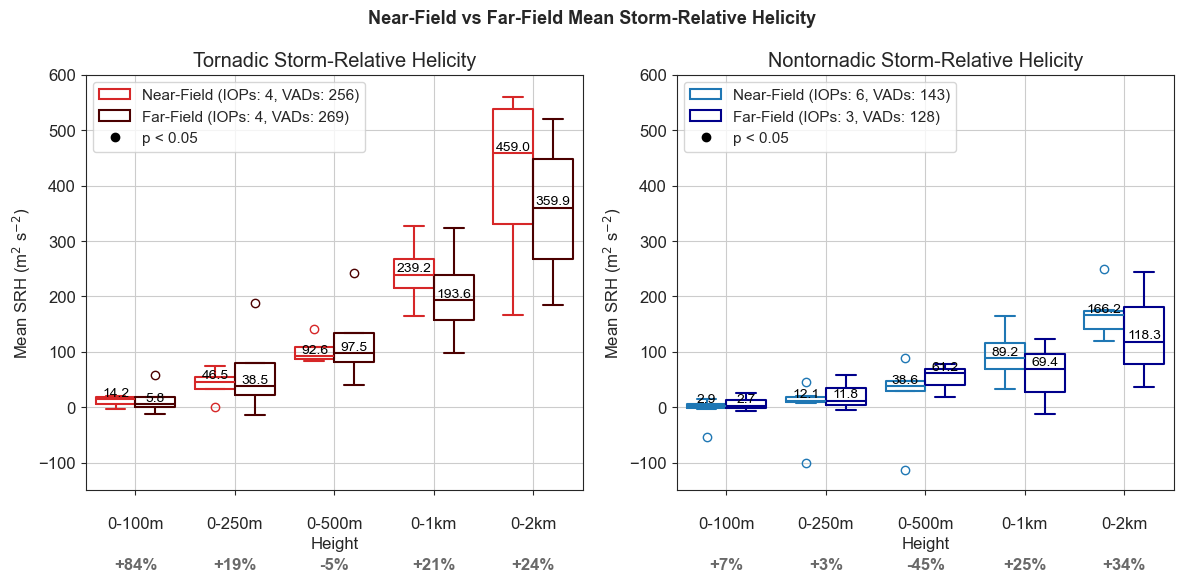

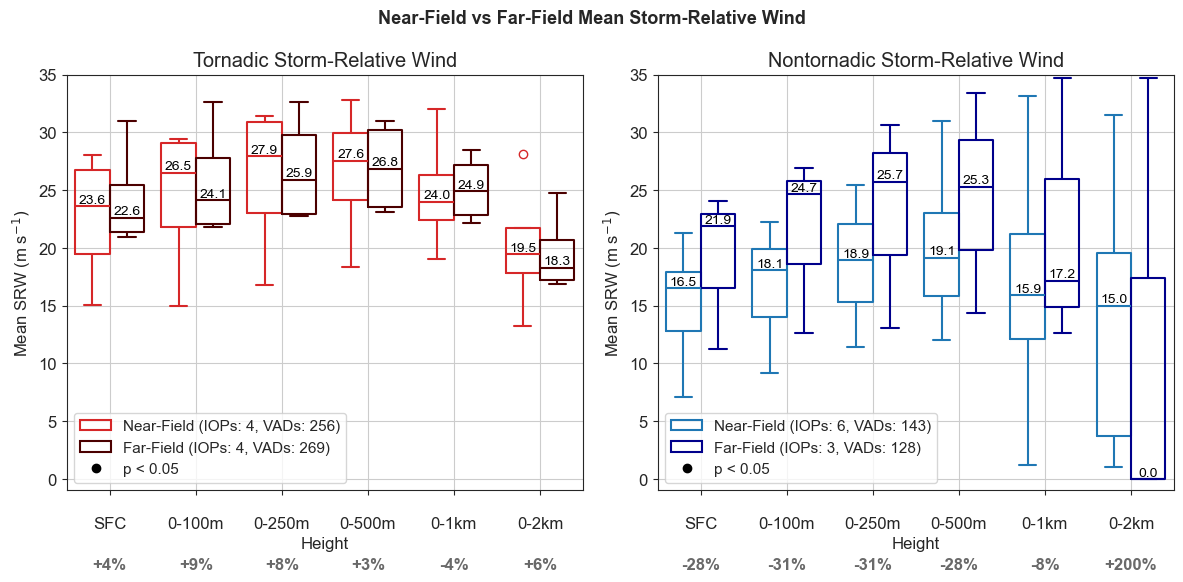

In [52]:
height_order = ['0-100m', '0-250m', '0-500m', '0-1km', '0-2km']
sfc_order = ['SFC', '0-100m', '0-250m', '0-500m', '0-1km', '0-2km']

plt.rcParams.update({'font.size': 12})

hue_order = ['nf', 'ff']
legend_labels = ['Near-field', 'Far-field']

plot_info = [
    ('SRH', height_order, 'Mean SRH (m$^{2}$ s$^{-2})$', (-150, 600)),
    ('SRW', sfc_order, 'Mean SRW (m s$^{-1})$', (-1, 35))
]

nf_dfs = []
for variable, order, ylabel, ylim in plot_info:

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    for ax, tnt, colors in zip(
        axes,
        ['tor', 'nontor'],
        [[ 'tab:red', very_dark_red], ['tab:blue', 'darkblue']]
    ):

        title = (
            f'{"Tornadic" if tnt=="tor" else "Nontornadic"} '
            f'{"Storm-Relative Helicity" if variable=="SRH" else "Storm-Relative Wind"}'
        )

        nf_pct_d = tor_nontor_boxplot(
            dist_angle_avg_date,
            variable,
            'Height',
            'Dist avg',
            'nf',
            'ff',
            True,
            tnt,
            'NF or FF',
            False,
            ylabel,
            title,
            ax,
            colors,
            order,
            hue_order,
            legend_labels
        )
        
        nf_pct_d['Tor or Nontor'] = tnt

        nf_dfs.append(nf_pct_d)

        ax.set_ylim(*ylim)

        # ----- Legend -----
        df = df_all_new[
            (df_all_new['u or v'] == 'v') &
            (df_all_new['Angle'] <= 90) &
            (df_all_new['Distance'] <= 50) &
            (df_all_new['Tor or Nontor'] == tnt)
        ]

        vad_counts = df['NF or FF'].value_counts()

        dist_angle = dist_angle_avg_date[
            (dist_angle_avg_date['Height'] == '0-1km') &
            (dist_angle_avg_date['SRW or SRH'] == 'SRH') &
            (dist_angle_avg_date['Tor or Nontor'] == tnt) &
            (dist_angle_avg_date['Dist avg'].notna())
        ]

        iop_counts = dist_angle.groupby('NF or FF').size()

        edgecolors = (
            {'nf': 'tab:red', 'ff': very_dark_red}
            if tnt == 'tor'
            else {'nf': 'tab:blue', 'ff': 'darkblue'}
        )

        label_map = {'nf': 'Near-Field', 'ff': 'Far-Field'}

        legend_patches = [
            Patch(
                facecolor='none',
                edgecolor=edgecolors[field],
                linewidth=1.5,
                label=f"{label_map[field]} "
                      f"(IOPs: {iop_counts.get(field,0)}, "
                      f"VADs: {vad_counts.get(field,0)})"
            )
            for field in edgecolors
            if field in iop_counts
        ]

                # Add significance marker
        legend_patches.append(
            Line2D(
                [0], [0],
                marker='o',
                color='black',
                linestyle='None',
                markersize=6,
                label='p < 0.05'
            )
        )
        
        labels = legend_labels + ['p < 0.05']

        ax.legend(handles=legend_patches,
                  loc='upper left',
                  fontsize=11,
                  frameon=True)

        if variable == 'SRW':
                ax.legend(handles=legend_patches,
                  loc='lower left',
                  fontsize=11,
                  frameon=True)

        full_word = (
        f'{"Storm-Relative Helicity" if variable=="SRH" else "Storm-Relative Wind"}'
    )

    fig.suptitle(
        f'Near-Field vs Far-Field Mean {full_word}',
        fontweight='bold',
        fontsize=13
    )

    plt.tight_layout()
    plt.show()

dist_perdiff_df = pd.concat(nf_dfs, ignore_index=True)

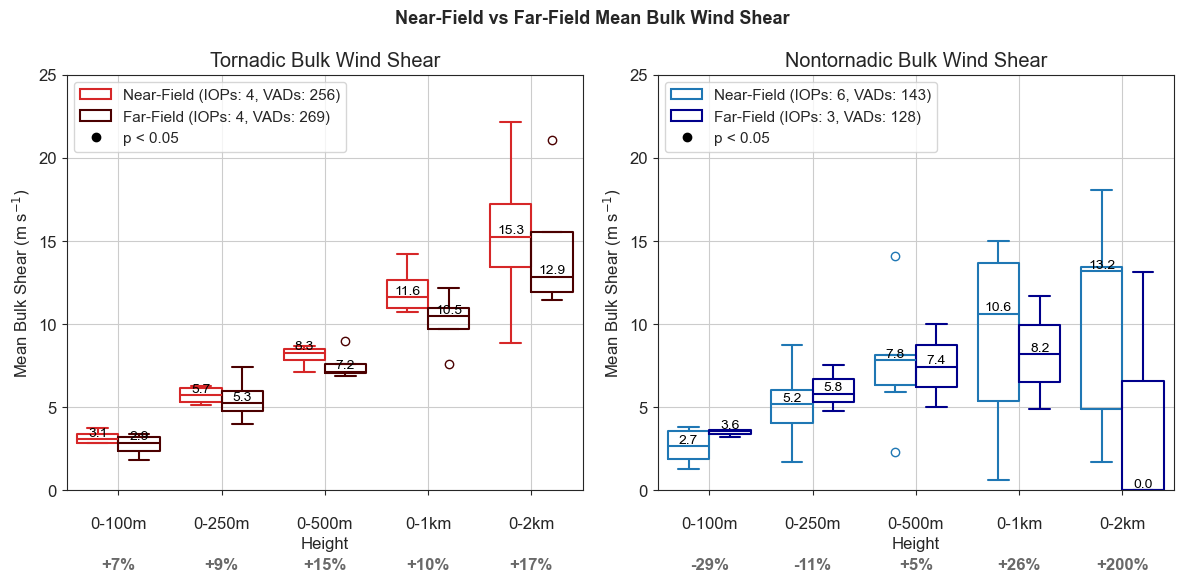

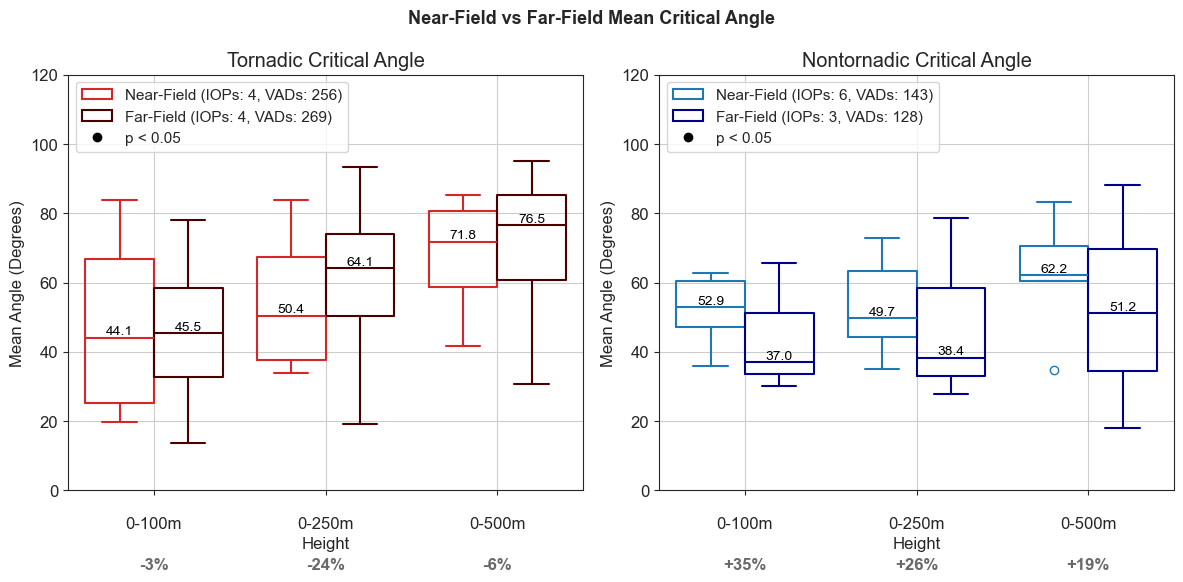

In [53]:
height_order = ['0-100m', '0-250m', '0-500m', '0-1km', '0-2km']
ca_order = ['0-100m', '0-250m', '0-500m']

plt.rcParams.update({'font.size': 12})

hue_order = ['nf', 'ff']
legend_labels = ['Near-field', 'Far-field']

plot_info = [
    ('Bulk Shear', height_order, 'Mean Bulk Shear (m s$^{-1})$', (0, 25)),
    ('Critical Angle', ca_order, 'Mean Angle (Degrees)', (0, 120))
]

nf_dfs = []
for variable, order, ylabel, ylim in plot_info:

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    for ax, tnt, colors in zip(
        axes,
        ['tor', 'nontor'],
        [[ 'tab:red', very_dark_red], ['tab:blue', 'darkblue']]
    ):

        title = (
            f'{"Tornadic" if tnt=="tor" else "Nontornadic"} '
            f'{"Bulk Wind Shear" if variable=="Bulk Shear" else "Critical Angle"}'
        )

        nf_pct_d = tor_nontor_boxplot(
            dist_angle_avg_date,
            variable,
            'Height',
            'Dist avg',
            'nf',
            'ff',
            True,
            tnt,
            'NF or FF',
            False,
            ylabel,
            title,
            ax,
            colors,
            order,
            hue_order,
            legend_labels
        )
        
        nf_pct_d['Tor or Nontor'] = tnt

        nf_dfs.append(nf_pct_d)

        ax.set_ylim(*ylim)

        # ----- Legend -----
        df = df_all_new[
            (df_all_new['u or v'] == 'v') &
            (df_all_new['Angle'] <= 90) &
            (df_all_new['Distance'] <= 50) &
            (df_all_new['Tor or Nontor'] == tnt)
        ]

        vad_counts = df['NF or FF'].value_counts()

        dist_angle = dist_angle_avg_date[
            (dist_angle_avg_date['Height'] == '0-1km') &
            (dist_angle_avg_date['SRW or SRH'] == 'SRH') &
            (dist_angle_avg_date['Tor or Nontor'] == tnt) &
            (dist_angle_avg_date['Dist avg'].notna())
        ]

        iop_counts = dist_angle.groupby('NF or FF').size()

        edgecolors = (
            {'nf': 'tab:red', 'ff': very_dark_red}
            if tnt == 'tor'
            else {'nf': 'tab:blue', 'ff': 'darkblue'}
        )

        label_map = {'nf': 'Near-Field', 'ff': 'Far-Field'}

        legend_patches = [
            Patch(
                facecolor='none',
                edgecolor=edgecolors[field],
                linewidth=1.5,
                label=f"{label_map[field]} "
                      f"(IOPs: {iop_counts.get(field,0)}, "
                      f"VADs: {vad_counts.get(field,0)})"
            )
            for field in edgecolors
            if field in iop_counts
        ]

        # Add significance marker
        legend_patches.append(
            Line2D(
                [0], [0],
                marker='o',
                color='black',
                linestyle='None',
                markersize=6,
                label='p < 0.05'
            )
        )
        
        labels = legend_labels + ['p < 0.05']

        ax.legend(handles=legend_patches,
                  loc='upper left',
                  fontsize=11,
                  frameon=True)

        if variable == 'SRW':
                ax.legend(handles=legend_patches,
                  loc='lower left',
                  fontsize=11,
                  frameon=True)

        full_word = (
        f'{"Bulk Wind Shear" if variable=="Bulk Shear" else "Critical Angle"}'
    )

    fig.suptitle(
        f'Near-Field vs Far-Field Mean {full_word}',
        fontweight='bold',
        fontsize=13
    )

    plt.tight_layout()
    plt.show()

dist_perdiff_ca_df = pd.concat(nf_dfs, ignore_index=True)

In [54]:
dist_angle_avg_date[
    (dist_angle_avg_date['Tor or Nontor'] == 'nontor') &
    (dist_angle_avg_date['SRW or SRH'] == 'SRW') &
    (dist_angle_avg_date['Height'] == '0-2km')
]

,Date,Height,SRW or SRH,NF or FF,Dist avg,Tor or Nontor,Azimuth,Angle avg
330,20220524,0-2km,SRW,ff,NaN,nontor,NaN,NaN
331,20220524,0-2km,SRW,nf,11.138351,nontor,NaN,NaN
368,20230611,0-2km,SRW,ff,NaN,nontor,NaN,NaN
369,20230611,0-2km,SRW,nf,19.845890,nontor,NaN,NaN
406,20230613,0-2km,SRW,ff,NaN,nontor,NaN,NaN
407,20230613,0-2km,SRW,nf,18.884675,nontor,NaN,NaN
444,20240427,0-2km,SRW,ff,34.736230,nontor,NaN,NaN
445,20240427,0-2km,SRW,nf,31.500556,nontor,NaN,NaN
482,20240501,0-2km,SRW,ff,0.000000,nontor,NaN,NaN
483,20240501,0-2km,SRW,nf,1.064739,nontor,NaN,NaN


In [55]:
df_all_new[df_all_new['Date'] == '20220524'].value_counts('NF or FF')

NF or FF
nf    100
Name: count, dtype: int64